Title: DSC 680: Project 1: Evaluating MLB Trade Deadline Moves Through Predicted WAR 

Author: Matthew Heinen

Date: 17 September 2025

Modified By: Matthew Heinen

Description: This project reads in cleans and gathersa the essential data to train and evaluate predictive model predicting a players future war. This project then usees thes models to project futur player performance of players who were traded at the MLB trade deadline. This is done with the purpose of evaluating the value of return ecat team recieves in the trade.

# Read in / Wrangle Data

Here we eill read in data from all of our sources as well as merge them into one readable file so that we have all the pitcher statistics as well as the coresponding WAR. 

In [230]:
# First read in data from MLB Statcast 

# Import Packages 
import pandas as pd

# read csv
player_stats = pd.read_csv('stats.csv')

#preview
player_stats.head(5)


,"last_name, first_name",player_id,year,player_age,p_game,p_formatted_ip,pa,ab,hit,single,...,breaking_avg_break,breaking_range_speed,n_offspeed_formatted,offspeed_avg_speed,offspeed_avg_spin,offspeed_avg_break_x,offspeed_avg_break_z,offspeed_avg_break_z_induced,offspeed_avg_break,offspeed_range_speed
0,"Pérez, Oliver",424144,2021,39,5,3.2,18,17,5,5,...,9.7,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Wainwright, Adam",425794,2021,39,32,206.1,828,765,168,111,...,22.2,1.9,6.4,82.7,1714.0,-13.8,-32.1,7.7,16.0,1.6
2,"Greinke, Zack",425844,2021,37,30,171.0,697,652,164,105,...,12.5,7.2,22.3,86.4,1594.0,-12.8,-32.1,4.5,13.7,1.2
3,"Santana, Ervin",429722,2021,38,38,65.1,277,251,65,38,...,5.4,2.5,3.3,87.2,1681.0,-8.0,-23.0,12.9,15.4,2.0
4,"Kazmir, Scott",431148,2021,37,5,11.1,55,48,15,9,...,8.4,2.0,30.9,80.5,1482.0,13.4,-34.2,7.9,15.7,1.6


In [231]:
# find the shape of the dataframe to determine how many variables and records in the set
player_stats.shape

(3929, 207)

In [232]:
# Split the "last_name, first_name" column and create a new "name" column
player_stats['name'] = player_stats['last_name, first_name'].str.split(', ').apply(
    lambda x: f"{x[1]} {x[0]}" if len(x) > 1 else x[0]
)

# Preview the dataframe with the new column
player_stats.head(5)

,"last_name, first_name",player_id,year,player_age,p_game,p_formatted_ip,pa,ab,hit,single,...,breaking_range_speed,n_offspeed_formatted,offspeed_avg_speed,offspeed_avg_spin,offspeed_avg_break_x,offspeed_avg_break_z,offspeed_avg_break_z_induced,offspeed_avg_break,offspeed_range_speed,name
0,"Pérez, Oliver",424144,2021,39,5,3.2,18,17,5,5,...,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Oliver Pérez
1,"Wainwright, Adam",425794,2021,39,32,206.1,828,765,168,111,...,1.9,6.4,82.7,1714.0,-13.8,-32.1,7.7,16.0,1.6,Adam Wainwright
2,"Greinke, Zack",425844,2021,37,30,171.0,697,652,164,105,...,7.2,22.3,86.4,1594.0,-12.8,-32.1,4.5,13.7,1.2,Zack Greinke
3,"Santana, Ervin",429722,2021,38,38,65.1,277,251,65,38,...,2.5,3.3,87.2,1681.0,-8.0,-23.0,12.9,15.4,2.0,Ervin Santana
4,"Kazmir, Scott",431148,2021,37,5,11.1,55,48,15,9,...,2.0,30.9,80.5,1482.0,13.4,-34.2,7.9,15.7,1.6,Scott Kazmir


In [233]:
# Read in WAR data from fangraphs. 
# YEar 2024

#read csv
pit_war_24 = pd.read_csv('fangraphs-war-leaderboard.csv')

# Add a 'year' column with value 2024 to all records
pit_war_24['year'] = 2024

# Preview df 
pit_war_24.head(5) 


,Name,Team,PA,IP,Bat WAR,Pit WAR,Total WAR,PlayerId,year
0,Aaron Judge,NYY,704.0,NaN,11.329109,NaN,11.329109,15640,2024
1,Bobby Witt Jr.,KCR,709.0,NaN,10.479079,NaN,10.479079,25764,2024
2,Shohei Ohtani,LAD,731.0,NaN,8.952518,NaN,8.952518,19755,2024
3,Juan Soto,NYY,713.0,NaN,8.285021,NaN,8.285021,20123,2024
4,Gunnar Henderson,BAL,719.0,NaN,7.940532,NaN,7.940532,26289,2024


In [234]:
# Read in WAR data from fangraphs. 
# YEar 2025

#read csv
pit_war_25 = pd.read_csv('fangraphs-war-leaderboard (1).csv')

# Add a 'year' column with value 2025 to all records
pit_war_25['year'] = 2025

# Preview df 
pit_war_25.head(5) 


,Name,Team,PA,IP,Bat WAR,Pit WAR,Total WAR,PlayerId,year
0,Aaron Judge,NYY,652.0,NaN,9.200006,NaN,9.200006,15640,2025
1,Shohei Ohtani,LAD,704.0,41.0,7.250475,1.579565,8.830040,19755,2025
2,Cal Raleigh,SEA,678.0,NaN,8.781865,NaN,8.781865,21534,2025
3,Bobby Witt Jr.,KCR,659.0,NaN,7.704574,NaN,7.704574,25764,2025
4,Geraldo Perdomo,ARI,692.0,NaN,6.908167,NaN,6.908167,22799,2025


In [235]:
# Read in WAR data from fangraphs. 
# YEar 2023

#read csv
pit_war_23 = pd.read_csv('fangraphs-war-leaderboard (2).csv')

# Add a 'year' column with value 2023 to all records
pit_war_23['year'] = 2023

# Preview df 
pit_war_23.head(5) 

,Name,Team,PA,IP,Bat WAR,Pit WAR,Total WAR,PlayerId,year
0,Ronald Acuña Jr.,ATL,735.0,NaN,9.143379,NaN,9.143379,18401,2023
1,Shohei Ohtani,LAA,599.0,132.0,6.581863,2.290122,8.871985,19755,2023
2,Freddie Freeman,LAD,730.0,NaN,7.705377,NaN,7.705377,5361,2023
3,Mookie Betts,LAD,693.0,NaN,7.604586,NaN,7.604586,13611,2023
4,Matt Olson,ATL,720.0,NaN,6.595669,NaN,6.595669,14344,2023


In [236]:
# Read in WAR data from fangraphs. 
# YEar 2022

#read csv
pit_war_22 = pd.read_csv('fangraphs-war-leaderboard (3).csv')

# Add a 'year' column with value 2022 to all records
pit_war_22['year'] = 2022

# Preview df 
pit_war_22.head(5) 

,Name,Team,PA,IP,Bat WAR,Pit WAR,Total WAR,PlayerId,year
0,Aaron Judge,NYY,696.0,NaN,11.097879,NaN,11.097879,15640,2022
1,Shohei Ohtani,LAA,666.0,166.0,3.614345,5.593072,9.207417,19755,2022
2,Nolan Arenado,STL,620.0,NaN,7.208796,NaN,7.208796,9777,2022
3,Manny Machado,SDP,644.0,NaN,7.128688,NaN,7.128688,11493,2022
4,Jose Altuve,HOU,604.0,NaN,6.861330,NaN,6.861330,5417,2022


In [237]:
# Read in WAR data from fangraphs. 
# YEar 2021

#read csv
pit_war_21 = pd.read_csv('fangraphs-war-leaderboard (4).csv')

# Add a 'year' column with value 2023 to all records
pit_war_21['year'] = 2021

# Preview df 
pit_war_21.head(5) 

,Name,Team,PA,IP,Bat WAR,Pit WAR,Total WAR,PlayerId,year
0,Shohei Ohtani,LAA,639.0,130.3333,5.017931,2.959517,7.977449,19755,2021
1,Corbin Burnes,MIL,59.0,167.0000,0.117416,7.472195,7.589611,19361,2021
2,Zack Wheeler,PHI,73.0,213.3333,0.088868,7.221505,7.310373,10310,2021
3,Trea Turner,- - -,646.0,NaN,7.127414,NaN,7.127414,16252,2021
4,Juan Soto,WSN,654.0,NaN,6.789302,NaN,6.789302,20123,2021


In [238]:
# Read in WAR data from fangraphs. 
# YEar 2020

#read csv
pit_war_20 = pd.read_csv('fangraphs-war-leaderboard (5).csv')

# Add a 'year' column with value 2020 to all records
pit_war_20['year'] = 2020

# Preview df 
pit_war_20.head(5) 

,Name,Team,PA,IP,Bat WAR,Pit WAR,Total WAR,PlayerId,year
0,Fernando Tatis Jr.,SDP,257.0,NaN,3.314397,NaN,3.314397,19709,2020
1,Shane Bieber,CLE,NaN,77.3333,0.000000,3.149900,3.149900,19427,2020
2,José Ramírez,CLE,254.0,NaN,3.109814,NaN,3.109814,13510,2020
3,Freddie Freeman,ATL,262.0,NaN,2.976279,NaN,2.976279,5361,2020
4,Yu Darvish,CHC,NaN,76.0000,0.000000,2.931952,2.931952,13074,2020


In [239]:
# Append all years of WAR data into a single dataframe
import pandas as pd
pit_war = pd.concat([pit_war_20, pit_war_21, pit_war_22, pit_war_23, pit_war_24, pit_war_25], ignore_index=True)    

In [240]:
# perform a series of merges with all of the war dataframes to append the WAR statistics for each player and season. 
# Left merge
# on name and year 

merged_df = pd.merge(player_stats, pit_war, how='left', left_on=['name', 'year'], right_on=['Name', 'year'])
merged_df.shape

(3941, 216)

In [241]:
# Filter to only include records where Total war is not null. 

filtered_df = merged_df[merged_df['Total WAR'].notnull()]

# find the shape 
filtered_df.shape

(3893, 216)

# Handle missing Data and Outliers. 

In [242]:
# Print the columns that are missing values and the percentage of missing values for each column
# Do this for all columns in the dataframe
missing_values = filtered_df.isnull().sum()
missing_percentage = (missing_values / len(filtered_df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data[missing_data['Missing Values'] > 0])


                      Missing Values  Percentage
p_opp_batting_avg               3893  100.000000
p_opp_on_base_avg               3893  100.000000
avg_swing_speed                 1704   43.770871
fast_swing_rate                 1704   43.770871
blasts_contact                  1704   43.770871
...                              ...         ...
offspeed_avg_break               686   17.621372
offspeed_range_speed             773   19.856152
PA                              3462   88.928847
IP                                 7    0.179810
Pit WAR                            7    0.179810

[138 rows x 2 columns]


In [243]:
# Remove the two columns that are missing all values
# 100% missing rate 
filtered_df = filtered_df.drop(columns=['p_opp_batting_avg', 'p_opp_on_base_avg'])



In [244]:
# Fill the missing values on all othe columns with the median of each column
for column in filtered_df.columns:
    if filtered_df[column].isnull().any():
        median_value = filtered_df[column].median()
        filtered_df[column].fillna(median_value, inplace=True)      

In [245]:
# PReview the filtered Dataframe shape and remaining columns 
print(filtered_df.shape)
print(filtered_df.columns)

(3893, 214)
Index(['last_name, first_name', 'player_id', 'year', 'player_age', 'p_game',
       'p_formatted_ip', 'pa', 'ab', 'hit', 'single',
       ...
       'offspeed_range_speed', 'name', 'Name', 'Team', 'PA', 'IP', 'Bat WAR',
       'Pit WAR', 'Total WAR', 'PlayerId'],
      dtype='object', length=214)


In [246]:
# Remove personaly identifiable information
# Keep one name column
filtered_df = filtered_df.drop(columns=['PlayerId', 'Name', 'last_name, first_name', 'Team', 'player_id'])

# EDA

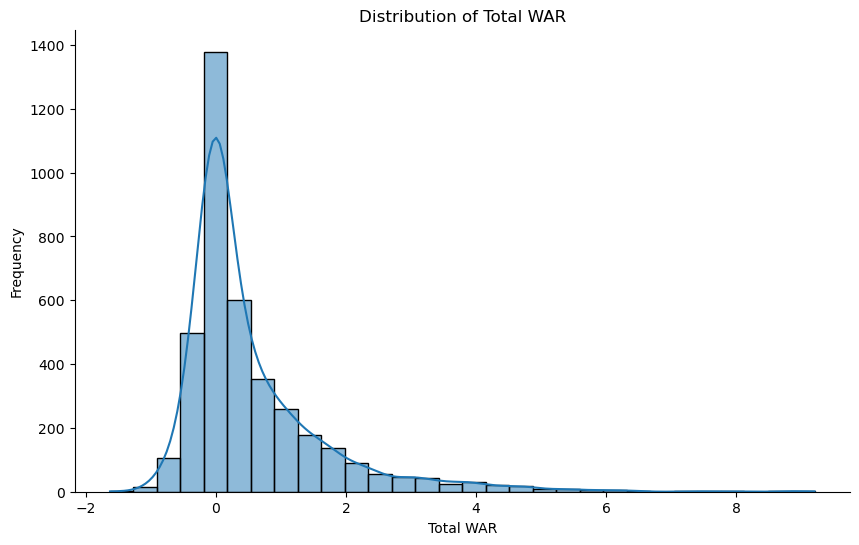

In [247]:
# Create a histogram of the Total WAR distribution
import matplotlib.pyplot as plt
import seaborn as sns
# EDA
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['Total WAR'], bins=30, kde=True)
plt.title('Distribution of Total WAR')
plt.xlabel('Total WAR')
plt.ylabel('Frequency')
# Remove top and right borders 
sns.despine()
plt.show()

As We can see the Total war is skewed to the right as expected. This makes sense because a WAR or win above replacement is a measuer of a major leagu players value in wins greater than that of a minor league player or a replacement. Players who produce a WAR of zero are seen as replacable. 

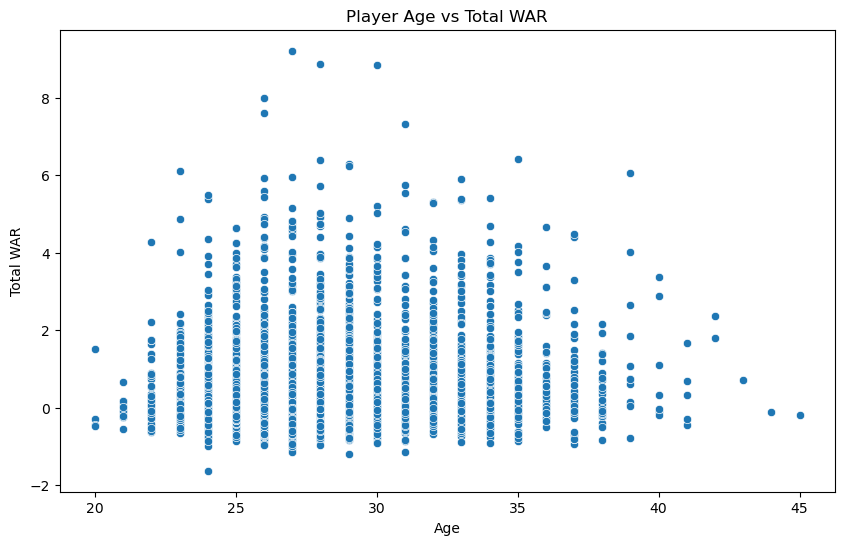

In [248]:
# Build a scatter plot showing relationship between player age and Total WAR
plt.figure(figsize=(10, 6))
sns.scatterplot(x='player_age', y='Total WAR', data=filtered_df)
plt.title('Player Age vs Total WAR')
plt.xlabel('Age')
plt.ylabel('Total WAR')
plt.show()


No obvious interaction/ relationship between age and war here may a slight quadratic relationship. 

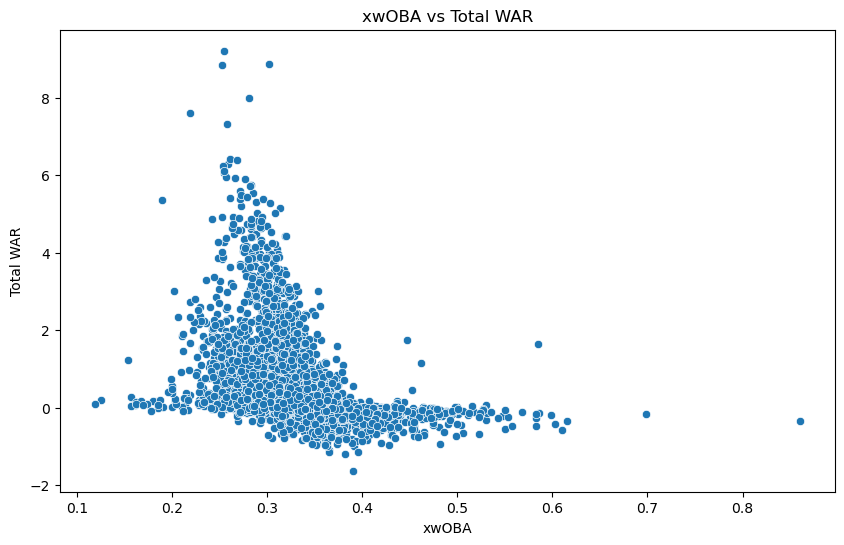

In [249]:
# Show relatioship between XWOBA and Total WAR
plt.figure(figsize=(10, 6))
sns.scatterplot(x='xwoba', y='Total WAR', data=filtered_df)
plt.title('xwOBA vs Total WAR')
plt.xlabel('xwOBA')
plt.ylabel('Total WAR')
plt.show()

Generally we see pitchers with low weighted on base average perform better in war. 

In [281]:
# Preview the filtered DF 
filtered_df.head(5)

,year,player_age,p_game,p_formatted_ip,pa,ab,hit,single,double,triple,...,offspeed_avg_break_z_induced,offspeed_avg_break,offspeed_range_speed,name,PA,IP,Bat WAR,Pit WAR,Total WAR,next_season_total_war
0,2021,39,5,3.2,18,17,5,5,0,0,...,5.7,15.9,1.4,Oliver Pérez,4.0,3.6666,0.000000,0.079721,0.079721,-0.127339
1,2021,39,32,206.1,828,765,168,111,34,2,...,7.7,16.0,1.6,Adam Wainwright,74.0,206.3333,0.105512,3.905633,4.011145,2.887493
2,2021,37,30,171.0,697,652,164,105,29,0,...,4.5,13.7,1.2,Zack Greinke,2.0,171.0000,-0.021114,1.208609,1.187495,1.93557
3,2021,38,38,65.1,277,251,65,38,16,2,...,12.9,15.4,2.0,Ervin Santana,4.0,65.3333,0.000000,0.096558,0.096558,None
4,2021,37,5,11.1,55,48,15,9,3,0,...,7.9,15.7,1.6,Scott Kazmir,4.0,11.3333,-0.042926,-0.154553,-0.197479,None


# Pepare a model data frame to predict Next Season Total War

In [251]:
# Add the column next season total war
# Loop though the years 2020-2024 and add the next season total war to a new column per player
filtered_df['next_season_total_war'] = None
for year in range(2020, 2025):
    next_year = year + 1
    for index, row in filtered_df[filtered_df['year'] == year].iterrows():
        player_name = row['name']
        next_season_war = filtered_df[(filtered_df['name'] == player_name) & (filtered_df['year'] == next_year)]['Total WAR']
        if not next_season_war.empty:
            filtered_df.at[index, 'next_season_total_war'] = next_season_war.values[0]

In [252]:
# Re assiign to model_df
model_df = filtered_df.copy()
# Perview
filtered_df.head(5)

,year,player_age,p_game,p_formatted_ip,pa,ab,hit,single,double,triple,...,offspeed_avg_break_z_induced,offspeed_avg_break,offspeed_range_speed,name,PA,IP,Bat WAR,Pit WAR,Total WAR,next_season_total_war
0,2021,39,5,3.2,18,17,5,5,0,0,...,5.7,15.9,1.4,Oliver Pérez,4.0,3.6666,0.000000,0.079721,0.079721,-0.127339
1,2021,39,32,206.1,828,765,168,111,34,2,...,7.7,16.0,1.6,Adam Wainwright,74.0,206.3333,0.105512,3.905633,4.011145,2.887493
2,2021,37,30,171.0,697,652,164,105,29,0,...,4.5,13.7,1.2,Zack Greinke,2.0,171.0000,-0.021114,1.208609,1.187495,1.93557
3,2021,38,38,65.1,277,251,65,38,16,2,...,12.9,15.4,2.0,Ervin Santana,4.0,65.3333,0.000000,0.096558,0.096558,None
4,2021,37,5,11.1,55,48,15,9,3,0,...,7.9,15.7,1.6,Scott Kazmir,4.0,11.3333,-0.042926,-0.154553,-0.197479,None


In [253]:
# Drop rows with null next season total war
# We cannot use these rows to train the model. 
model_df = model_df[model_df['next_season_total_war'].notnull()]

In [254]:
#Find the unique position values and their counts. 
model_df.shape

(2260, 210)

# Train Models

 ## Backwards stepwise regression 

In [255]:
# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['name', 'Total WAR', 'next_season_total_war']) 
target = model_df['next_season_total_war']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


# Ensure all features are numeric for modeling
features_train = features_train.apply(pd.to_numeric, errors='coerce')
features_test = features_test.apply(pd.to_numeric, errors='coerce')
target_train = pd.to_numeric(target_train, errors='coerce')
target_test = pd.to_numeric(target_test, errors='coerce')

In [256]:
# Build stepwise regression with a p value threshold of 0.05

# Load Libraries
import pandas as pd
import statsmodels.api as sm
import warnings
import numpy as np

# Suppress Warning
warnings.simplefilter("ignore", category=RuntimeWarning)

# Add a constant to the model (intercept)
features_train = sm.add_constant(features_train)

# Fit the initial model
model = sm.OLS(target_train, features_train).fit()

# Backward stepwise regression
while True:
    # Get the p-values of the model
    p_values = model.pvalues
    # Find the maximum p-value
    max_p_value = p_values.max()
    
    # If the maximum p-value is greater than 0.05, remove that variable
    if max_p_value > 0.05:
        # Identify the variable to remove
        variable_to_remove = p_values.idxmax()
         # Skip removing 'const'
        if variable_to_remove == 'const':
            break
        # Remove the variable from the model
        features_train = features_train.drop(variable_to_remove, axis=1)
        # Remove from test data as well 
        features_test = features_test.drop(variable_to_remove, axis=1)
        # Refit the model
        model = sm.OLS(target_train, features_train).fit()
    else:
        break

# Print the summary of the final model # Commented out for length, Includes too many features 
print("Final model summary:")
print(model.summary())

# Prepare the test set for prediction
# Add constant to test set
features_test_final = features_test.copy()
#features_test_final = sm.add_constant(features_test) 



Final model summary:
                              OLS Regression Results                             
Dep. Variable:     next_season_total_war   R-squared:                       0.497
Model:                               OLS   Adj. R-squared:                  0.461
Method:                    Least Squares   F-statistic:                     13.88
Date:                   Sun, 05 Oct 2025   Prob (F-statistic):          8.22e-177
Time:                           14:57:08   Log-Likelihood:                -2247.4
No. Observations:                   1808   AIC:                             4737.
Df Residuals:                       1687   BIC:                             5402.
Df Model:                            120                                         
Covariance Type:               nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [257]:
# Evaluate Fit 

# Load Libraries 
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
# Prepare the test set for prediction
features_test_final = features_test.copy()

# Add 'const' if needed
if 'const' in features_train.columns and 'const' not in features_test_final.columns:
    features_test_final = sm.add_constant(features_test_final, has_constant='add')

# Ensure columns match
features_test_final = features_test_final[features_train.columns]
# Predictions
train_predictions = model.predict(features_train)
test_predictions = model.predict(features_test_final)

# R² Calculation
r2_train = r2_score(target_train, train_predictions)
r2_test = r2_score(target_test, test_predictions)

# RMSE Calculation
rmse_train = np.sqrt(mean_squared_error(target_train, train_predictions))
rmse_test = np.sqrt(mean_squared_error(target_test, test_predictions))

# Output the results
print(" P-Value Threshold 0.05 BAckwards Stepwise Regression")
print(f"Training R²: {r2_train}, Training RMSE: {rmse_train}")
print(f"Test R²: {r2_test}, Test RMSE: {rmse_test}")

 P-Value Threshold 0.05 BAckwards Stepwise Regression
Training R²: 0.49679595965539214, Training RMSE: 0.8386895772856245
Test R²: 0.3528225744506932, Test RMSE: 0.9423213644827271


# Backwards stepwise regression with PCA and standard scaler

In [258]:
# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['name', 'Total WAR', 'next_season_total_war']) 
target = model_df['next_season_total_war']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


# Ensure all features are numeric for modeling
features_train = features_train.apply(pd.to_numeric, errors='coerce')
features_test = features_test.apply(pd.to_numeric, errors='coerce')
target_train = pd.to_numeric(target_train, errors='coerce')
target_test = pd.to_numeric(target_test, errors='coerce')

In [259]:
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
import numpy as np

warnings.simplefilter("ignore", category=RuntimeWarning)

scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

pca = PCA()
features_train_pca = pca.fit_transform(features_train_scaled)
features_test_pca = pca.transform(features_test_scaled)

# Convert to DataFrame for .drop() support
features_train_pca = pd.DataFrame(features_train_pca)
features_test_pca = pd.DataFrame(features_test_pca)

# Add constant for intercept
features_train_pca = sm.add_constant(features_train_pca)
features_test_pca = sm.add_constant(features_test_pca)

# Reset indices to ensure alignment
features_train_pca = features_train_pca.reset_index(drop=True)
features_test_pca = features_test_pca.reset_index(drop=True)
target_train = target_train.reset_index(drop=True)
target_test = target_test.reset_index(drop=True)

# Fit the initial model
model = sm.OLS(target_train, features_train_pca).fit()

while True:
    p_values = model.pvalues
    max_p_value = p_values.max()
    if max_p_value > 0.05:
        variable_to_remove = p_values.idxmax()
        if variable_to_remove == 'const':
            break
        features_train_pca = features_train_pca.drop(variable_to_remove, axis=1)
        features_test_pca = features_test_pca.drop(variable_to_remove, axis=1)
        model = sm.OLS(target_train, features_train_pca).fit()
    else:
        break

# Prepare the test set for prediction
features_test_final = features_test_pca.copy()

# Print the summary of the final model # Commented out for length 
print("Final model summary:")
print(model.summary())

Final model summary:
                              OLS Regression Results                             
Dep. Variable:     next_season_total_war   R-squared:                       0.463
Model:                               OLS   Adj. R-squared:                  0.445
Method:                    Least Squares   F-statistic:                     26.02
Date:                   Sun, 05 Oct 2025   Prob (F-statistic):          3.06e-193
Time:                           14:57:14   Log-Likelihood:                -2305.9
No. Observations:                   1808   AIC:                             4730.
Df Residuals:                       1749   BIC:                             5054.
Df Model:                             58                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

This model has 122 different significant predictors. This model may be very complicated to interpret and implement due to the high number of significant features. 

In [260]:
# Evaluate Fit 

# Load Libraries 
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Predictions
train_predictions = model.predict(features_train_pca)
test_predictions = model.predict(features_test_final)

# R² Calculation
r2_train = r2_score(target_train, train_predictions)
r2_test = r2_score(target_test, test_predictions)

# RMSE Calculation
rmse_train = np.sqrt(mean_squared_error(target_train, train_predictions))
rmse_test = np.sqrt(mean_squared_error(target_test, test_predictions))

# Output the results
print(" P-Value Threshold 0.05")
print(f"Training R²: {r2_train}, Training RMSE: {rmse_train}")
print(f"Test R²: {r2_test}, Test RMSE: {rmse_test}")

 P-Value Threshold 0.05
Training R²: 0.46316813334944595, Training RMSE: 0.8662601376571032
Test R²: 0.3515004447159483, Test RMSE: 0.9432834155315127


# Can I train a Neural network model to predict total war 

In [261]:
# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['name', 'Total WAR', 'next_season_total_war']) 
target = model_df['next_season_total_war']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


# Ensure all features are numeric for modeling
features_train = features_train.apply(pd.to_numeric, errors='coerce')
features_test = features_test.apply(pd.to_numeric, errors='coerce')
target_train = pd.to_numeric(target_train, errors='coerce')
target_test = pd.to_numeric(target_test, errors='coerce')

In [262]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(features_train)
X_test_scaled = scaler.transform(features_test)

# Build and train model
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, target_train)

# Predict
nn_predictions = mlp.predict(X_test_scaled)

# Evaluate Train Set
print("MLPRegressor Train R²:", r2_score(target_train, mlp.predict(X_train_scaled)))
print("MLPRegressor Train RMSE:", np.sqrt(mean_squared_error(target_train, mlp.predict(X_train_scaled))))

# Evaluate Test Set
print("MLPRegressor R²:", r2_score(target_test, nn_predictions))
print("MLPRegressor RMSE:", np.sqrt(mean_squared_error(target_test, nn_predictions)))

MLPRegressor Train R²: 0.9921080042551181
MLPRegressor Train RMSE: 0.10503223508534587
MLPRegressor R²: 0.027413970032737378
MLPRegressor RMSE: 1.1551845483454044


Serious signs of overfitting on this neural network model. Explains almost no variance in the data of the test set. 

Build a random forest


In [263]:
# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['name', 'Total WAR', 'next_season_total_war']) 
target = model_df['next_season_total_war']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


# Ensure all features are numeric for modeling
features_train = features_train.apply(pd.to_numeric, errors='coerce')
features_test = features_test.apply(pd.to_numeric, errors='coerce')
target_train = pd.to_numeric(target_train, errors='coerce')
target_test = pd.to_numeric(target_test, errors='coerce')

In [264]:
# Load libraries
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import warnings

# Suppress future warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Initialize the Min-Max scaler
mmscaler = MinMaxScaler()

# Define pipeline 
pipe = Pipeline([("MinMaxScaler", mmscaler), ("regressor", RandomForestRegressor())]) 

# Create dictionary with candidate learning algorithms and their hyperparameters
search_space = [
    # Linear Regression (no hyperparameters for grid search)
    {"regressor": [LinearRegression()]},
    # Random Forest Param
    {"regressor": [RandomForestRegressor()],
     "regressor__n_estimators": [10, 100, 1000], 
     "regressor__max_features": [1, 2, 3]},
    # Decision Tree Param
    {"regressor": [DecisionTreeRegressor()],
     "regressor__max_depth": [None, 2, 4, 6, 8, 10, 12, 20],
     "regressor__min_samples_split": [2, 5, 10],
     "regressor__min_samples_leaf": [1, 2, 4],
     "regressor__criterion": ['squared_error', 'friedman_mse']},
    # Bagging param
    {"regressor": [BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42)],
     "regressor__n_estimators": [10, 50, 100]},
    # Boosting decision tree param
    {"regressor": [AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1), random_state=42)],
     "regressor__n_estimators": [50, 100, 300],
     "regressor__learning_rate": [0.01, 0.1, 1.0]},
    # Gradient Boosting param
    {"regressor": [GradientBoostingRegressor(random_state=42)],
     "regressor__n_estimators": [50, 100, 300],
     "regressor__learning_rate": [0.01, 0.1, 0.2],
     "regressor__max_depth": [3, 5, 7]},
]

# Create grid search
gridsearch = GridSearchCV(pipe, search_space, cv=5, verbose=0)

# Fit gridsearch 
best_model = gridsearch.fit(features_train, target_train)

# Print Best model 
print("The best model is: ", best_model.best_estimator_)

The best model is:  Pipeline(steps=[('MinMaxScaler', MinMaxScaler()),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.01, n_estimators=300,
                                           random_state=42))])


In [265]:
#Find the R2 and RMSE for the training and test sets
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
# Predictions
train_predictions = best_model.predict(features_train)
test_predictions = best_model.predict(features_test)
# Evaluate Train Set
print("Best Estimator Train R²:", r2_score(target_train, train_predictions))
print("Best Estimator Train RMSE:", np.sqrt(mean_squared_error(target_train, train_predictions)))
# Evaluate Test Set
print("Best Estimator Test R²:", r2_score(target_test, test_predictions))
print("Best Estimator Test RMSE:", np.sqrt(mean_squared_error(target_test, test_predictions)))

Best Estimator Train R²: 0.5554431361687824
Best Estimator Train RMSE: 0.7883023952485619
Best Estimator Test R²: 0.3460816575047302
Best Estimator Test RMSE: 0.9472162006588407


In [266]:
#Find the best estimator
best_estimator = best_model.best_estimator_

# Get the feature names from df 
feature_names = features_train.columns

# Find the importances from the gradient boost classifier
importances = best_estimator.named_steps['regressor'].feature_importances_

# Create a DataFrame of the importances and sort by importance
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# only display the top 10 features of importance. 
feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(10)

# Print
print("Gradient Boosting Feature Importances (Sorted):")
print(feature_importance)

Gradient Boosting Feature Importances (Sorted):
                          Feature  Importance
206                       Pit WAR    0.529260
11                      strikeout    0.102394
203                            PA    0.027293
66            out_zone_swing_miss    0.026798
205                       Bat WAR    0.024467
180            fastball_avg_speed    0.023720
90                 ff_range_speed    0.016560
192  breaking_avg_break_z_induced    0.012045
13                      k_percent    0.011401
84                   ff_avg_speed    0.009827


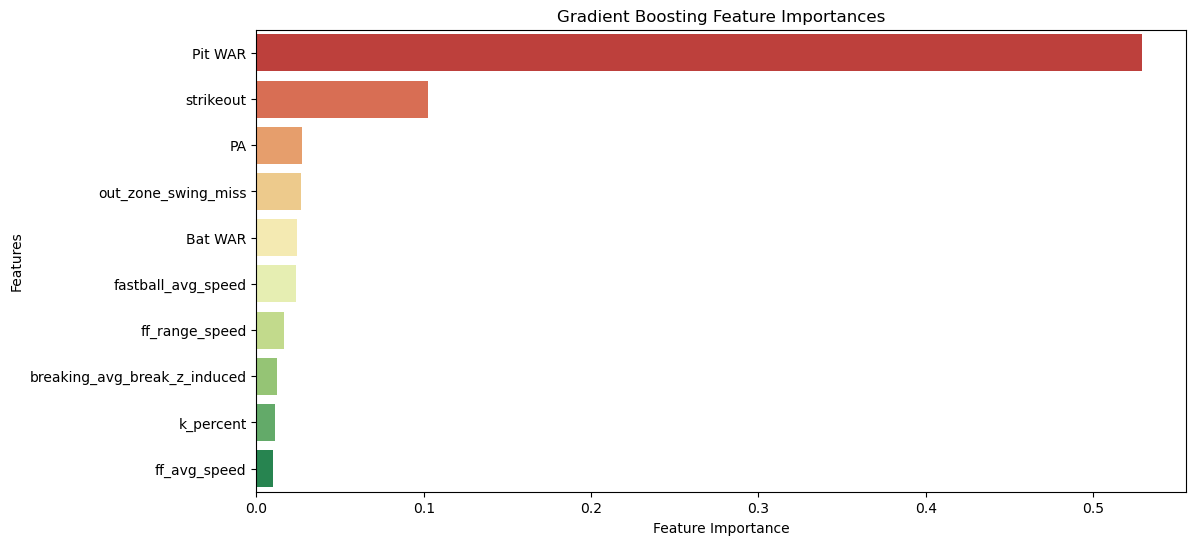

In [267]:
# Create a bar chart of the feature importances
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance['Importance'], y=feature_importance['Feature'], palette="RdYlGn") # RdYlGn palette
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Gradient Boosting Feature Importances")
plt.show()

Past year pitching war is a very high predictor. This is very logical and suggests that pitchers who were good in the previous season are likely to preform similarly in the future. 

In [268]:
# Apply the best model to predict 2026 WAR for players of interest.
# Use Johan Duran 2025 stats to predict 2026 WAR
# 2025 stats
jhoan_duran_2025 = filtered_df[(filtered_df['name'] == 'Jhoan Duran') & (filtered_df['year'] == 2025)]

# Mick Abel 2025 stats
mick_abel_2025 = filtered_df[(filtered_df['name'] == 'Mick Abel') & (filtered_df['year'] == 2025)]

# Griffin Jax 2025 stats
griffin_jax_2025 = filtered_df[(filtered_df['name'] == 'Griffin Jax') & (filtered_df['year'] == 2025)]

# Taj Bradley 2025 stats
taj_bradley_2025 = filtered_df[(filtered_df['name'] == 'Taj Bradley') & (filtered_df['year'] == 2025)]

# Kendry Rojas 2025 stats
kendry_rojas_2025 = filtered_df[(filtered_df['name'] == 'Kendry Rojas') & (filtered_df['year'] == 2025)]

# Predict 2026 WAR for Johan Duran
jhoan_duran_2026_war = best_model.predict(jhoan_duran_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war']))
print(f"Predicted 2026 WAR for Jhoan Duran: {jhoan_duran_2026_war[0]}")

# Predict 2026 WAR for Mick Abel
mick_abel_2026_war = best_model.predict(mick_abel_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war']))
print(f"Predicted 2026 WAR for Mick Abel: {mick_abel_2026_war[0]}") 
# Predict 2026 WAR for Griffin Jax
griffin_jax_2026_war = best_model.predict(griffin_jax_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war']))
print(f"Predicted 2026 WAR for Griffin Jax: {griffin_jax_2026_war[0]}")
# Predict 2026 WAR for Taj Bradley
taj_bradley_2026_war = best_model.predict(taj_bradley_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war']))
print(f"Predicted 2026 WAR for Taj Bradley: {taj_bradley_2026_war[0]}")
    

Predicted 2026 WAR for Jhoan Duran: 1.48351654082551
Predicted 2026 WAR for Mick Abel: 0.30546087363292845
Predicted 2026 WAR for Griffin Jax: 1.1191770053241974
Predicted 2026 WAR for Taj Bradley: 1.399116449980448


Evaluate the trades by projecting future war of all the minnesota twins pitcher for pitcher trades at the deadline. 

Pitcher <-> Pitcher trades to evaluate

Johan Duran - Mick Abel Phillies
Griffin Jax - Taj Bradley Rays
Louis Varland - Kendry Rojas Blue Jays

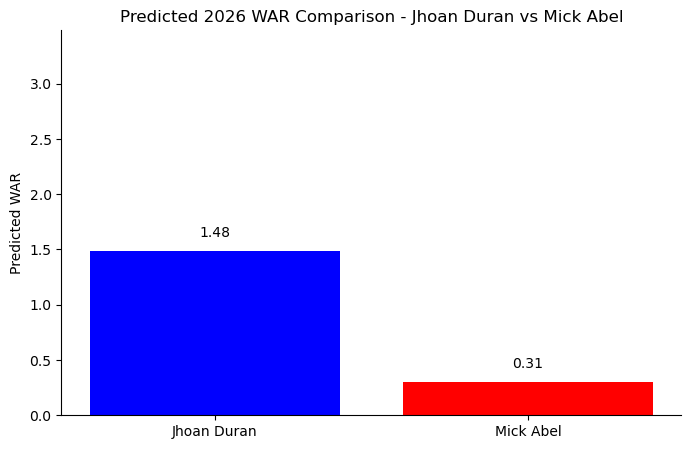

In [269]:
# Build a bar chart to compare the two players predicted 2026 WAR
import matplotlib.pyplot as plt
import numpy as np
players = ['Jhoan Duran', 'Mick Abel']
predicted_war = [jhoan_duran_2026_war[0], mick_abel_2026_war[0]]
plt.figure(figsize=(8, 5))
bars = plt.bar(players, predicted_war, color=['blue', 'red'])
plt.title('Predicted 2026 WAR Comparison - Jhoan Duran vs Mick Abel')
plt.ylabel('Predicted WAR')
# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')
plt.ylim(0, max(predicted_war) + 2)
# Remove top and right borders
import seaborn as sns
sns.despine()
plt.show()

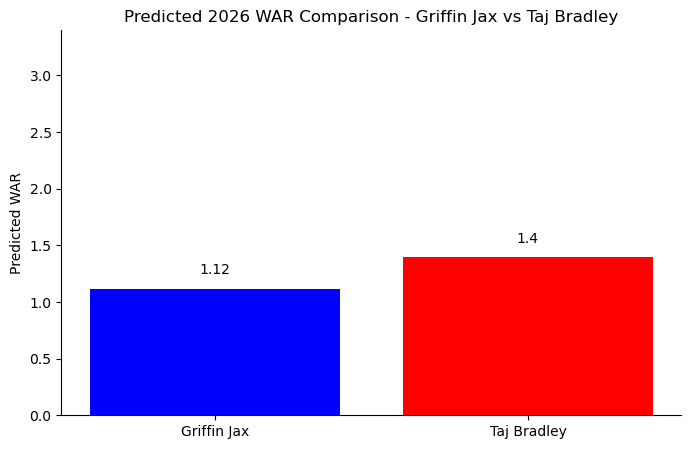

In [270]:
# Build a bar chart to compare the two players predicted 2026 WAR
import matplotlib.pyplot as plt
import numpy as np
players = ['Griffin Jax', 'Taj Bradley']
predicted_war = [griffin_jax_2026_war[0], taj_bradley_2026_war[0]]
plt.figure(figsize=(8, 5))
bars = plt.bar(players, predicted_war, color=['blue', 'red'])
plt.title('Predicted 2026 WAR Comparison - Griffin Jax vs Taj Bradley')
plt.ylabel('Predicted WAR')
# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')
plt.ylim(0, max(predicted_war) + 2)
# Remove top and right borders
import seaborn as sns
sns.despine()
plt.show()

In [271]:
features_train.shape

(1808, 207)

# Retrain the backwards stepwise model in order to apply it 

In [272]:
# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['name', 'Total WAR', 'next_season_total_war']) 
target = model_df['next_season_total_war']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


# Ensure all features are numeric for modeling
features_train = features_train.apply(pd.to_numeric, errors='coerce')
features_test = features_test.apply(pd.to_numeric, errors='coerce')
target_train = pd.to_numeric(target_train, errors='coerce')
target_test = pd.to_numeric(target_test, errors='coerce')

In [273]:
# Build stepwise regression with a p value threshold of 0.05

# Load Libraries
import pandas as pd
import statsmodels.api as sm
import warnings
import numpy as np

# Suppress Warning
warnings.simplefilter("ignore", category=RuntimeWarning)

# Add a constant to the model (intercept)
features_train = sm.add_constant(features_train)

# Fit the initial model
model = sm.OLS(target_train, features_train).fit()

# Backward stepwise regression
while True:
    # Get the p-values of the model
    p_values = model.pvalues
    # Find the maximum p-value
    max_p_value = p_values.max()
    
    # If the maximum p-value is greater than 0.05, remove that variable
    if max_p_value > 0.05:
        # Identify the variable to remove
        variable_to_remove = p_values.idxmax()
         # Skip removing 'const'
        if variable_to_remove == 'const':
            break
        # Remove the variable from the model
        features_train = features_train.drop(variable_to_remove, axis=1)
        # Remove from test data as well 
        features_test = features_test.drop(variable_to_remove, axis=1)
        # Refit the model
        model = sm.OLS(target_train, features_train).fit()
    else:
        break

# Print the summary of the final model # Commented out for length, Includes too many features 
#print("Final model summary:")
#print(model.summary())

# Prepare the test set for prediction
# Add constant to test set
features_test_final = features_test.copy()
#features_test_final = sm.add_constant(features_test) 

In [274]:
# Print all the features in the final model
print("Features in the final model:")
print(features_train.columns)

Features in the final model:
Index(['const', 'year', 'player_age', 'p_game', 'p_formatted_ip', 'pa', 'ab',
       'single', 'double', 'triple',
       ...
       'n_offspeed_formatted', 'offspeed_avg_speed', 'offspeed_avg_break_x',
       'offspeed_avg_break_z', 'offspeed_avg_break_z_induced',
       'offspeed_avg_break', 'offspeed_range_speed', 'PA', 'Bat WAR',
       'Pit WAR'],
      dtype='object', length=123)


Pitcher <-> Pitcher trades to evaluate

Johan Duran - Mick Abel Phillies
Griffin Jax - Taj Bradley Rays
Louis Varland - Kendry Rojas Blue Jays

In [275]:
# Use Johan Duran 2025 stats to predict 2026 WAR
# 2025 stats
jhoan_duran_2025 = filtered_df[(filtered_df['name'] == 'Jhoan Duran') & (filtered_df['year'] == 2025)]

# Mick Abel 2025 stats
mick_abel_2025 = filtered_df[(filtered_df['name'] == 'Mick Abel') & (filtered_df['year'] == 2025)]

# Griffin Jax 2025 stats
griffin_jax_2025 = filtered_df[(filtered_df['name'] == 'Griffin Jax') & (filtered_df['year'] == 2025)]


In [276]:
# use the model to predict 2026 WAR for both players

# Features set for both players
jhoan_duran_2025_features = jhoan_duran_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war'])
mick_abel_2025_features = mick_abel_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war'])

# Add constant and reindex to match training columns
jhoan_duran_2025_features = sm.add_constant(jhoan_duran_2025_features, has_constant='add')
mick_abel_2025_features = sm.add_constant(mick_abel_2025_features, has_constant='add')

jhoan_duran_2025_features = jhoan_duran_2025_features.reindex(columns=features_train.columns, fill_value=0)
mick_abel_2025_features = mick_abel_2025_features.reindex(columns=features_train.columns, fill_value=0)

# Predict
jhoan_duran_2026_war = model.predict(jhoan_duran_2025_features)
mick_abel_2026_war = model.predict(mick_abel_2025_features)

print(f"Predicted 2026 WAR for Johan Duran: {jhoan_duran_2026_war.values[0]}")
print(f"Predicted 2026 WAR for Mick Abel: {mick_abel_2026_war.values[0]}")

Predicted 2026 WAR for Johan Duran: 2.0578804648246867
Predicted 2026 WAR for Mick Abel: 0.6178779426690726


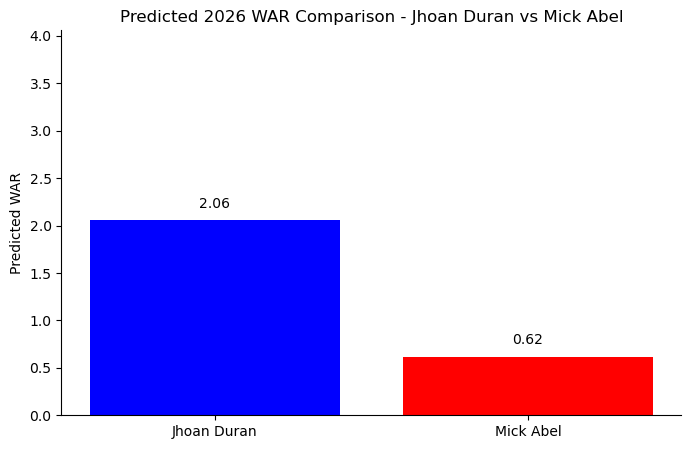

In [277]:
# Build a bar chart to compare the two players predicted 2026 WAR
import matplotlib.pyplot as plt
import numpy as np
players = ['Jhoan Duran', 'Mick Abel']
predicted_war = [jhoan_duran_2026_war.values[0], mick_abel_2026_war.values[0]]
plt.figure(figsize=(8, 5))
bars = plt.bar(players, predicted_war, color=['blue', 'red'])
plt.title('Predicted 2026 WAR Comparison - Jhoan Duran vs Mick Abel')
plt.ylabel('Predicted WAR')
# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')
plt.ylim(0, max(predicted_war) + 2)
# Remove top and right borders
import seaborn as sns
sns.despine()
plt.show()

Repeat the process Griffin Jax - Taj Bradley Rays

In [278]:
# 2025 stats Griffin Jax
griffin_jax_2025 = filtered_df[(filtered_df['name'] == 'Griffin Jax') & (filtered_df['year'] == 2025)]

# Taj Bradley 2025 stats
# 2025 stats
taj_bradley_2025 = filtered_df[(filtered_df['name'] == 'Taj Bradley') & (filtered_df['year'] == 2025)]


In [279]:
# use the model to predict 2026 WAR for both players

# Features set for both players
griffin_jax_2025_features = griffin_jax_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war'])
taj_bradley_2025_features = taj_bradley_2025.drop(columns=['name', 'Total WAR', 'next_season_total_war'])

# Add constant and reindex to match training columns
griffin_jax_2025_features = sm.add_constant(griffin_jax_2025_features, has_constant='add')
taj_bradley_2025_features = sm.add_constant(taj_bradley_2025_features, has_constant='add')

griffin_jax_2025_features = griffin_jax_2025_features.reindex(columns=features_train.columns, fill_value=0)
taj_bradley_2025_features = taj_bradley_2025_features.reindex(columns=features_train.columns, fill_value=0)

# Predict
griffin_jax_2026_war = model.predict(griffin_jax_2025_features)
taj_bradley_2026_war = model.predict(taj_bradley_2025_features)

print(f"Predicted 2026 WAR for Griffin Jax: {griffin_jax_2026_war.values[0]}")
print(f"Predicted 2026 WAR for Taj Bradley: {taj_bradley_2026_war.values[0]}")

Predicted 2026 WAR for Griffin Jax: 1.535976354894696
Predicted 2026 WAR for Taj Bradley: 1.1756691432088504


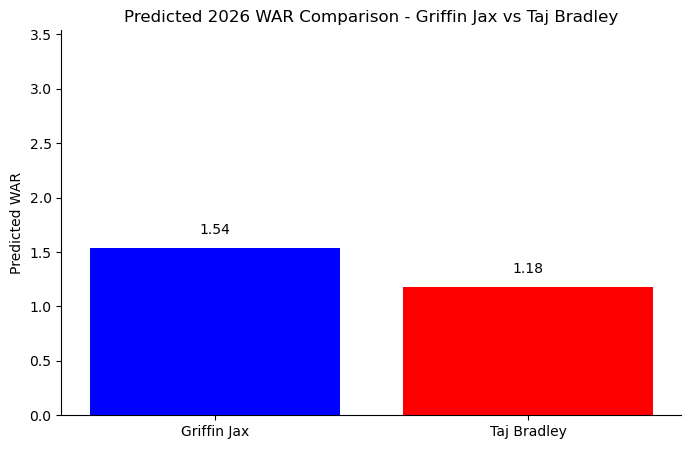

In [280]:
# Build a bar chart to compare the two players predicted 2026 WAR
import matplotlib.pyplot as plt
import numpy as np
players = ['Griffin Jax', 'Taj Bradley']
predicted_war = [griffin_jax_2026_war.values[0], taj_bradley_2026_war.values[0]]
plt.figure(figsize=(8, 5))
bars = plt.bar(players, predicted_war, color=['blue', 'red'])
plt.title('Predicted 2026 WAR Comparison - Griffin Jax vs Taj Bradley')
plt.ylabel('Predicted WAR')
# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')
plt.ylim(0, max(predicted_war) + 2)
# Remove top and right borders
import seaborn as sns
sns.despine()
plt.show()